In [1]:
import xarray as xr
import pandas as pd


ds = xr.open_dataset("single-point-timeseries_all_vars.nc")


print(ds)


df = ds.to_dataframe().reset_index()


print(df.columns)


print(df.head())

<xarray.Dataset> Size: 948kB
Dimensions:     (valid_time: 26328)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 211kB 2023-01-01 ... 2026-01-01T2...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    u10         (valid_time) float32 105kB ...
    v10         (valid_time) float32 105kB ...
    t2m         (valid_time) float32 105kB ...
    sp          (valid_time) float32 105kB ...
    ssrd        (valid_time) float32 105kB ...
    tcc         (valid_time) float32 105kB ...
    tp          (valid_time) float32 105kB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts
Index(['valid_time', 'u10', 'v10', 't2m', 'sp', '

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26328 entries, 0 to 26327
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   valid_time  26328 non-null  datetime64[ns]
 1   u10         26328 non-null  float32       
 2   v10         26328 non-null  float32       
 3   t2m         26328 non-null  float32       
 4   sp          26328 non-null  float32       
 5   ssrd        26328 non-null  float32       
 6   tcc         26328 non-null  float32       
 7   tp          26328 non-null  float32       
 8   latitude    26328 non-null  float64       
 9   longitude   26328 non-null  float64       
dtypes: datetime64[ns](1), float32(7), float64(2)
memory usage: 1.3 MB
None


In [3]:
# NaN
print(df.isna().sum())

valid_time    0
u10           0
v10           0
t2m           0
sp            0
ssrd          0
tcc           0
tp            0
latitude      0
longitude     0
dtype: int64


In [4]:
print(df["valid_time"].duplicated().sum())

0


In [5]:
print(df["valid_time"].diff().value_counts())

valid_time
0 days 01:00:00    26327
Name: count, dtype: int64


# Initial XGBoost Baseline

A first XGBoost regression model was trained using lag features and rolling statistics in order to predict precipitation at 17:00 each day.

The model was initially evaluated using a simple chronological train-test split.

In [6]:
df = df.drop(columns=["latitude", "longitude"])


In [7]:
df["hour"] = df["valid_time"].dt.hour
df["dayofyear"] = df["valid_time"].dt.dayofyear
df["month"] = df["valid_time"].dt.month

In [8]:
lags = [1, 3, 6, 12, 24, 48, 72]

# Variables used as predictors
# tp is excluded because it is the target variable
vars_to_lag = ["t2m", "sp", "tcc", "u10", "v10"]

#lags = [1, 3, 6, 12, 24, 48, 72]



for var in vars_to_lag:
    for lag in lags:
        df[f"{var}_lag{lag}"] = df[var].shift(lag)

In [9]:

df["tcc_roll24_mean"] = df["tcc"].rolling(24).mean()
df["sp_roll24_mean"] = df["sp"].rolling(24).mean()
df["t2m_roll24_mean"] = df["t2m"].rolling(24).mean()
df["u10_roll24_mean"] = df["u10"].rolling(24).mean()
df["v10_roll24_mean"] = df["v10"].rolling(24).mean()
#df = df.dropna().copy()

In [11]:
X = df.drop(columns=["valid_time", "tp"], errors="ignore")
# Extra safety: remove any accidental tp-derived feature
X = X[[col for col in X.columns if not col.startswith("tp")]]

y = df["tp"]

In [28]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

time_train = df["valid_time"].iloc[:train_end]
time_val = df["valid_time"].iloc[train_end:val_end]
time_test = df["valid_time"].iloc[val_end:]

In [29]:
print("Train:", time_train.min(), "to", time_train.max(), X_train.shape)
print("Validation:", time_val.min(), "to", time_val.max(), X_val.shape)
print("Test:", time_test.min(), "to", time_test.max(), X_test.shape)

Train: 2023-01-01 00:00:00 to 2025-02-06 20:00:00 (18429, 49)
Validation: 2025-02-06 21:00:00 to 2025-07-21 09:00:00 (3949, 49)
Test: 2025-07-21 10:00:00 to 2026-01-01 23:00:00 (3950, 49)


In [30]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [31]:
pred = model.predict(X_test)
mask_17_test = time_test.dt.hour == 17

y_test_17 = y_test[mask_17_test]
pred_17 = pred[mask_17_test]

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_17, pred_17)
rmse = np.sqrt(mean_squared_error(y_test_17, pred_17))
corr = np.corrcoef(y_test_17, pred_17)[0,1]

print("Test metrics at 17:00")
print("MAE:", mae)
print("RMSE:", rmse)
print("Correlation:", corr)

Test metrics at 17:00
MAE: 0.00013285687600728124
RMSE: 0.0003342603289356904
Correlation: 0.43359180197373726


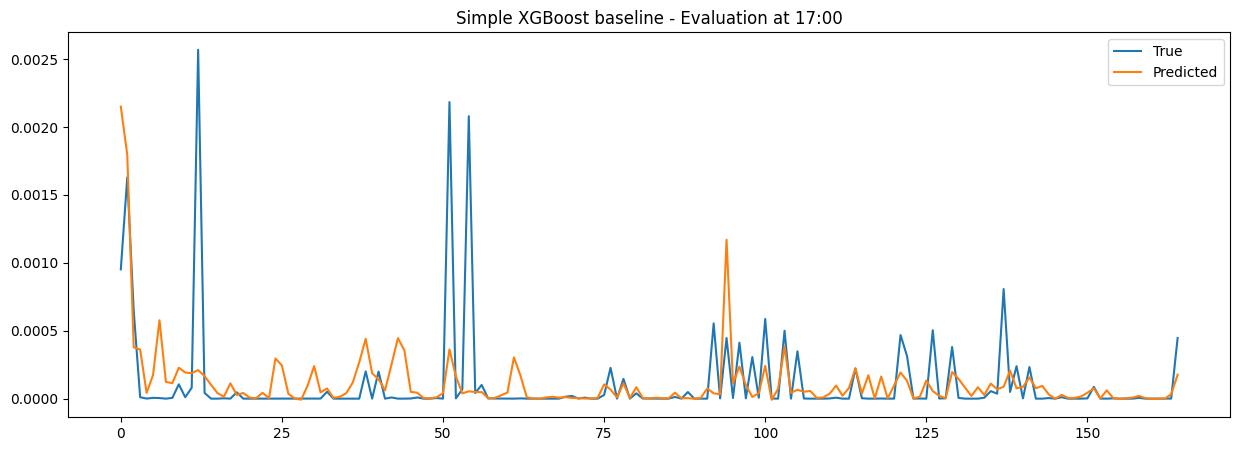

In [33]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(15,5))

plt.plot(y_test_17.values[:200], label="True")
plt.plot(pred_17[:200], label="Predicted")

plt.title("Simple XGBoost baseline - Evaluation at 17:00")
plt.legend()
plt.show()

In [34]:
print(y_test_17.head(10))
print(y_test_17.index[:10])
print(y_test_17.shape)
print(y_test_17.describe())

22385    9.517670e-04
22409    1.629353e-03
22433    6.475449e-04
22457    1.049042e-05
22481    4.768372e-07
22505    5.722046e-06
22529    4.291534e-06
22553    0.000000e+00
22577    5.722046e-06
22601    1.053810e-04
Name: tp, dtype: float32
Index([22385, 22409, 22433, 22457, 22481, 22505, 22529, 22553, 22577, 22601], dtype='int64')
(165,)
count    1.650000e+02
mean     1.132040e-04
std      3.576544e-04
min      0.000000e+00
25%      0.000000e+00
50%      4.768372e-07
75%      2.002716e-05
max      2.568245e-03
Name: tp, dtype: float64


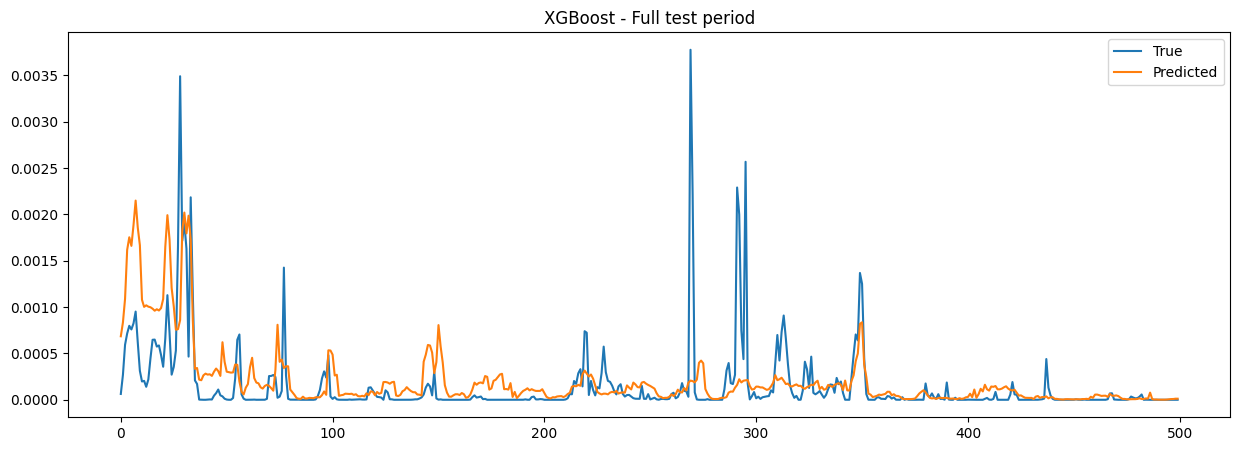

In [35]:
pred = model.predict(X_test)

plt.figure(figsize=(15,5))

plt.plot(y_test.values[:500], label="True")
plt.plot(pred[:500], label="Predicted")

plt.title("XGBoost - Full test period")
plt.legend()
plt.show()

# Improved Validation Strategy

The dataset was further divided into chronological training, validation, and test sets in order to perform more reliable model evaluation and hyperparameter tuning while avoiding temporal leakage.

In [36]:
"""
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]
"""

'\nn = len(df)\n\ntrain_end = int(n * 0.70)\nval_end = int(n * 0.85)\n\nX_train = X.iloc[:train_end]\ny_train = y.iloc[:train_end]\n\nX_val = X.iloc[train_end:val_end]\ny_val = y.iloc[train_end:val_end]\n\nX_test = X.iloc[val_end:]\ny_test = y.iloc[val_end:]\n'

In [37]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred_val = model.predict(X_val)

In [38]:
weights_train = np.where(y_train > 0, 5, 1)

In [39]:
model_w = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_w.fit(
    X_train,
    y_train,
    sample_weight=weights_train
)

pred_val_w = model_w.predict(X_val)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    
    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("Correlation:", corr)

evaluate(y_val, pred_val, "Baseline XGBoost")
evaluate(y_val, pred_val_w, "Weighted XGBoost")

Baseline XGBoost
MAE: 8.148599590640515e-05
RMSE: 0.00024647087825212515
Correlation: 0.42127592870733865
Weighted XGBoost
MAE: 9.53919516177848e-05
RMSE: 0.00024062553076406191
Correlation: 0.46589604211910135


Weighted XGBoost @ 17:00
MAE: 0.00013546472473535687
RMSE: 0.0003195797065512669
Correlation: 0.27147454552879124


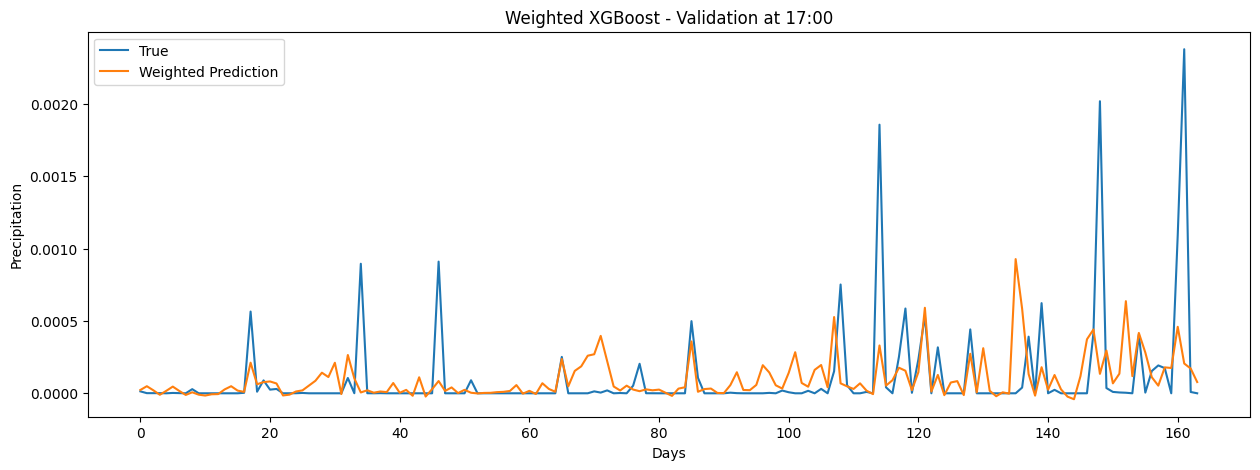

In [43]:
mask_17_val = time_val.dt.hour == 17
y_val_17 = y_val[mask_17_val]
pred_val_w_17 = pred_val_w[mask_17_val.values]

evaluate(y_val_17, pred_val_w_17, "Weighted XGBoost @ 17:00")

plt.figure(figsize=(15,5))
plt.plot(y_val_17.values[:200], label="True")
plt.plot(pred_val_w_17[:200], label="Weighted Prediction")
plt.xlabel("Days")
plt.ylabel("Precipitation")
plt.title("Weighted XGBoost - Validation at 17:00")
plt.legend()
plt.show()

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
#from xgboost import XGBRegressor

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 1]
}
tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train,
    sample_weight=weights_train
)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 1],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5, 10],
                                        'n_estimators': [200, 300, 500, 800],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [53]:
print(random_search.best_params_)

{'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}


In [54]:
best_model = random_search.best_estimator_

pred_val_best = best_model.predict(X_val)

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("Correlation:", corr)

mask_17_val = time_val.dt.hour == 17

evaluate_model(y_val[mask_17_val], pred_val[mask_17_val.values],      "Baseline XGBoost @ 17:00")
evaluate_model(y_val[mask_17_val], pred_val_w[mask_17_val.values],    "Weighted XGBoost @ 17:00")
evaluate_model(y_val[mask_17_val], pred_val_best[mask_17_val.values], "Tuned Weighted XGBoost @ 17:00")

Baseline XGBoost @ 17:00
MAE: 0.00012146364315412939
RMSE: 0.00031936863939364274
Correlation: 0.26123802754533
Weighted XGBoost @ 17:00
MAE: 0.00013546472473535687
RMSE: 0.0003195797065512669
Correlation: 0.27147454552879124
Tuned Weighted XGBoost @ 17:00
MAE: 0.0001348483783658594
RMSE: 0.00032614583229758547
Correlation: 0.2656530398773933


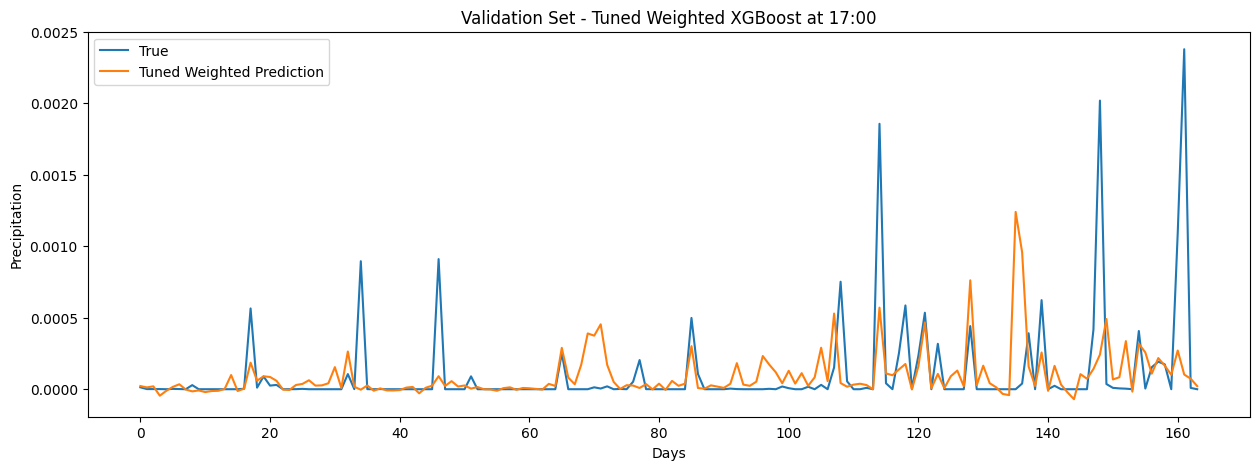

In [56]:
mask_17_val = time_val.dt.hour == 17

plt.figure(figsize=(15,5))
plt.plot(y_val[mask_17_val].values[:200], label="True")
plt.plot(pred_val_best[mask_17_val.values][:200], label="Tuned Weighted Prediction")

plt.xlabel("Days")
plt.ylabel("Precipitation")
plt.title("Validation Set - Tuned Weighted XGBoost at 17:00")
plt.legend()
plt.show()

# Log-Transformed and Weighted XGBoost Regression

The precipitation target variable is highly imbalanced, with many near-zero values and relatively few intense rainfall events. This often leads to underestimation of large precipitation peaks in standard regression models.

To address this issue, a logarithmic transformation was applied to the target variable using:

y = log(1 + tp)

This transformation compresses extreme precipitation values and produces a more stable target distribution for regression.

In addition, sample weighting was introduced during training in order to increase the importance of rainfall events, particularly heavier precipitation cases, which are underrepresented in the dataset.

The tuned XGBoost model was then retrained using:
- logarithmically transformed precipitation targets,
- weighted samples,
- and the previously optimized hyperparameters.

In [58]:
import numpy as np

y = np.log1p(df["tp"])

In [59]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [60]:
weights_train = 1 + 5000 * np.expm1(y_train)

In [61]:
from xgboost import XGBRegressor

model_log = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_log.fit(
    X_train,
    y_train,
    sample_weight=weights_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [62]:
pred_log = model_log.predict(X_val)

In [63]:
pred_tp = np.expm1(pred_log)

y_val_tp = np.expm1(y_val)

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mask_17_val = time_val.dt.hour == 17

mae = mean_absolute_error(y_val_tp[mask_17_val], pred_tp[mask_17_val.values])
rmse = np.sqrt(mean_squared_error(y_val_tp[mask_17_val], pred_tp[mask_17_val.values]))
corr = np.corrcoef(y_val_tp[mask_17_val], pred_tp[mask_17_val.values])[0,1]

print("MAE:", mae)
print("RMSE:", rmse)
print("Correlation:", corr)

MAE: 0.0001541615929454565
RMSE: 0.00034472555387815487
Correlation: 0.2600218176623642


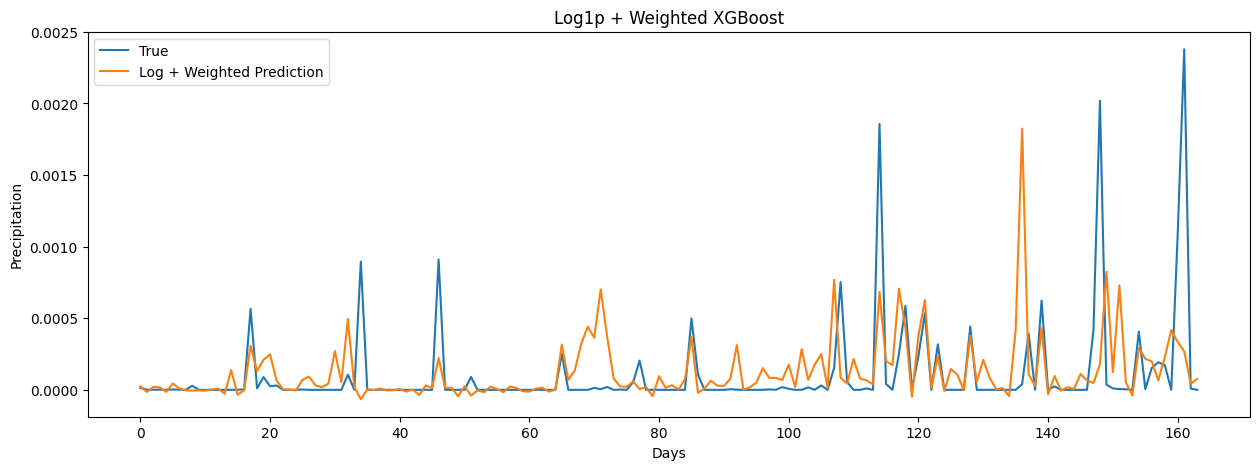

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))


plt.plot(y_val_tp[mask_17_val].values[:200], label="True")
plt.plot(pred_tp[mask_17_val.values][:200], label="Log + Weighted Prediction")
plt.xlabel("Days")
plt.ylabel("Precipitation")
plt.title("Log1p + Weighted XGBoost")

plt.legend()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

mask_17_val = time_val.dt.hour == 17

result = permutation_importance(
    model_log,
    X_val[mask_17_val],
    y_val[mask_17_val],  
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(20)

,feature,importance_mean,importance_std
27,tcc_lag24,0.000034,0.000049
12,t2m_lag12,0.000034,0.000015
13,t2m_lag24,0.000030,0.000020
2,t2m,0.000030,0.000005
9,t2m_lag1,0.000029,0.000006
3,sp,0.000007,0.000006
10,t2m_lag3,0.000007,0.000003
32,u10_lag6,0.000007,0.000004
18,sp_lag6,0.000006,0.000003
15,t2m_lag72,0.000006,0.000002


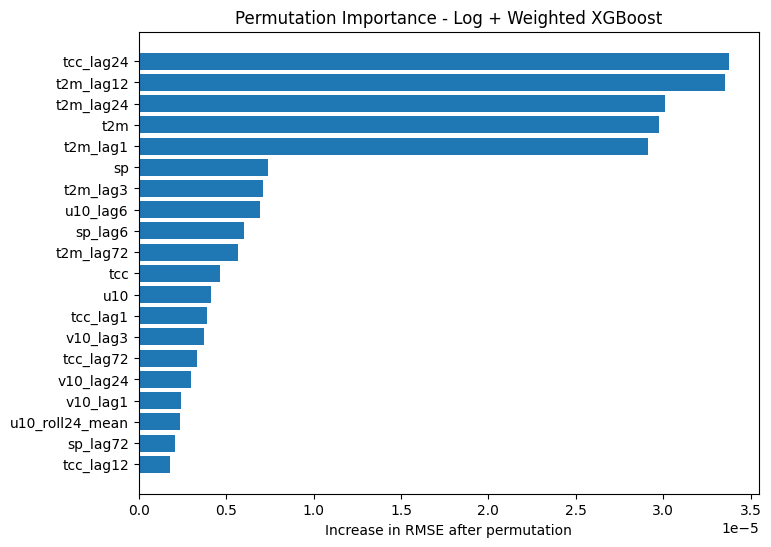

In [67]:
top_n = 20

plt.figure(figsize=(8, 6))

plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["importance_mean"].head(top_n)[::-1]
)

plt.xlabel("Increase in RMSE after permutation")
plt.title("Permutation Importance - Log + Weighted XGBoost")
plt.show()

Log + Weighted XGBoost @ 17:00 - TEST
MAE: 0.0001901828363770619
RMSE: 0.00036622733229083716
Correlation: 0.46006691589856397


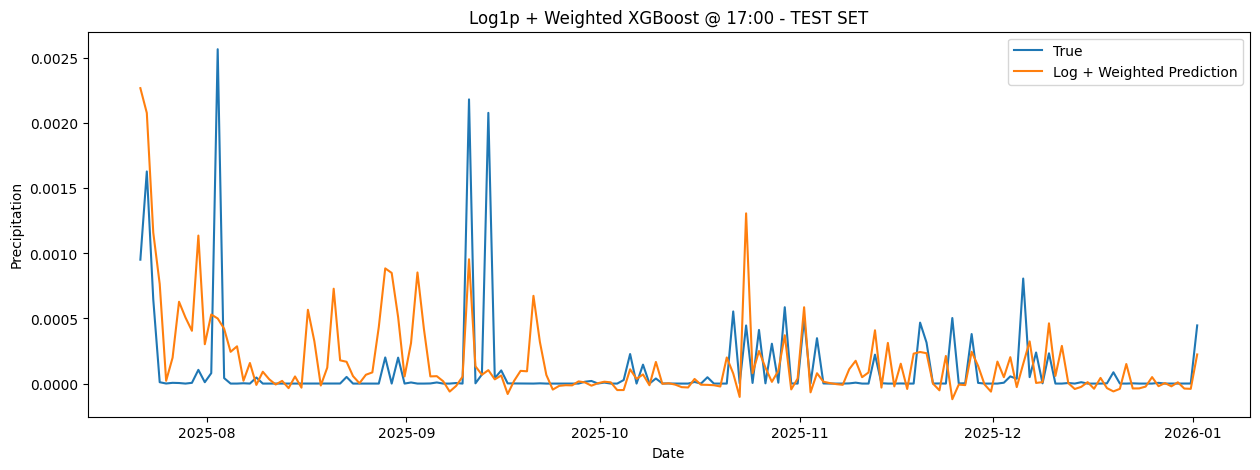

In [70]:
pred_log_test = model_log.predict(X_test)
pred_tp_test = np.expm1(pred_log_test)
y_test_tp = np.expm1(y_test)

mask_17_test = time_test.dt.hour == 17

evaluate_model(y_test_tp[mask_17_test], pred_tp_test[mask_17_test.values], "Log + Weighted XGBoost @ 17:00 - TEST")

time_test_17 = time_test[mask_17_test]

plt.figure(figsize=(15,5))
plt.plot(time_test_17.values[:200], y_test_tp[mask_17_test].values[:200], label="True")
plt.plot(time_test_17.values[:200], pred_tp_test[mask_17_test.values][:200], label="Log + Weighted Prediction")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("Log1p + Weighted XGBoost @ 17:00 - TEST SET")
plt.legend()
plt.show()